# Community Citation Analysis 

Making use of a community citation analysis to identify groups/communities in the behavious of works citing each other.

In [2]:
#import necessary packages
import networkx as nx
import numpy as np
from community import community_louvain #pip install python-louvain package
import leidenalg as la
import igraph as ig
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Read the data

Read the data generated by get_data_openalex.ipynb notebook.

In [3]:
fake_data = 0
toprint = 0 #Flag to print information (turn off if using a large dataset!)

In [4]:
# Load the data
data_file = '../data/openAlex/test/pub2ref_OA.csv'
if fake_data == 1: 
    data_file = '../data/fake/citation_data_fake.csv'
citation_data = pd.read_csv(data_file)

#citation_data = citation_data[0:1000]

In [5]:
print("Information of the data being used:")
print()
citation_data.info()
print()
print(citation_data.head(20))

Information of the data being used:

<class 'pandas.DataFrame'>
RangeIndex: 29276 entries, 0 to 29275
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   publication_id  29276 non-null  str  
 1   reference_id    29276 non-null  str  
dtypes: str(2)
memory usage: 2.2 MB

                      publication_id                      reference_id
0   https://openalex.org/W2184854514     https://openalex.org/W9119819
1   https://openalex.org/W2184854514    https://openalex.org/W35899286
2   https://openalex.org/W2184854514   https://openalex.org/W627963485
3   https://openalex.org/W2184854514   https://openalex.org/W768552817
4   https://openalex.org/W2184854514  https://openalex.org/W1499933681
5   https://openalex.org/W2184854514  https://openalex.org/W1549940068
6   https://openalex.org/W2184854514  https://openalex.org/W1565485882
7   https://openalex.org/W2184854514  https://openalex.org/W1574930552
8   https://openal

## Perform the community analysis

Makes use [networkx](https://networkx.org/documentation/stable/) package, [igraph](https://python.igraph.org/en/stable/) package.

### Set up the graphs 

A `Graph` is a collection of nodes (in this case, works) and edges (in this case lines representing citations between works). Should identify pairs of nodes (i.e., in this case, two works that have a citation link between them). We are using OpenAlex IDs to define nodes in this example. Our tables are effectively a long list of edges because we have created a list of every pair of citations (sources and targets or publication_ids and reference_ids). So we use the citation_data to add all of these edges to the Graph.

With `iGraph` object, we can do fast manipulation and analysis. [`ig.Graph.TupleList`](https://python.igraph.org/en/main/api/igraph.Graph.html#TupleList) constructs a graph for a list of tuples (which is what we had in out `Graph`. We have set directed=True, which I think keeps track of the direction of the edge (i.e., which is the citing and which is the cited work in this case).

In [6]:
# Create a directed graph
G_networkX = nx.DiGraph()#create an empty graph

if fake_data == 1:
    G_networkX.add_edges_from(citation_data[['source', 'target']].values) 
else: G_networkX.add_edges_from(citation_data[['publication_id', 'reference_id']].values) #create the edges

# Convert the NetworkX graph to an iGraph object
g_iGraph = ig.Graph.TupleList(G_networkX.edges(), directed=True)

### Perform the partition

Uses the [leidenalg](https://leidenalg.readthedocs.io/en/stable/intro.html) package. This is seems to be behaving well on the fake data I generated, recovering the citation communities I artificially created.

In [7]:
# Perform Leiden community detection (note the number of iterations is how many times the algorithm is used, if make it negative then runs until not improvement)
partition = la.find_partition(g_iGraph, la.ModularityVertexPartition, n_iterations=-3)

# Get the community assignments
community_ids = partition.membership

### Tidy and print some information about the communities identified

In [8]:
if toprint == 1: 
    print(partition)
print()

#Print overview of communities identied
print("")
print("----Partition Overview----")
print("Number of nodes (elements):",partition.n)
print("Number of communities:",len(partition))
print("")



----Partition Overview----
Number of nodes (elements): 22106
Number of communities: 206



In [9]:
# Create a dictionary mapping nodes to community IDs
node_community = {node: community_id for node, community_id in zip(G_networkX.nodes(), community_ids)}

### Calculate some community metrics

Will go to each community and get the size (i.e., the number of works in the community) and density of each of these.

The [density](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.density.html) is 0 for a graph without edges and 1 for a complete graph. The density of multigraphs can be higher than 1.

In [11]:
community_nodes_list = []

#Create a dictionary of the information about the community metrics
community_metrics = {}
for community_id in set(community_ids):
    #get number of works (nodes) in each community
    community_nodes = [node for node, cid in node_community.items() if cid == community_id]
    #get density in each node [what is this?!?!]
    community_nodes_list.append(community_nodes)
    community_graph = G_networkX.subgraph(community_nodes)
    community_metrics[community_id] = {
        'size': len(community_nodes),
        'density': nx.density(community_graph)
    }

# Print community metrics (number of papers in each community and the density)
for community_id, metrics in community_metrics.items():
    print(f"Community {community_id}: size={metrics['size']}, density={metrics['density']}")
print("-------------")
print("")
if toprint == 1: 
    print(community_metrics)

Community 0: size=1931, density=0.0003431871053952018
Community 1: size=1249, density=0.0003137125084683131
Community 2: size=1158, density=0.00040229704897574726
Community 3: size=873, density=0.001004918187836943
Community 4: size=532, density=0.0004000113277544143
Community 5: size=502, density=0.0009224578730984246
Community 6: size=496, density=0.0005213424568263278
Community 7: size=478, density=0.0014517161829074674
Community 8: size=458, density=0.000692765615892521
Community 9: size=405, density=0.0008006356191174673
Community 10: size=389, density=0.0015371160522619457
Community 11: size=371, density=0.0004370947767174182
Community 12: size=362, density=0.0006504338776572137
Community 13: size=361, density=0.0014773776546629731
Community 14: size=360, density=0.0011374187558031569
Community 15: size=347, density=0.000649664340090953
Community 16: size=342, density=0.0007974481658692185
Community 17: size=337, density=0.0010774339409354247
Community 18: size=324, density=0.000

<h1>Make figure</h1>

We want to make a figure showing the communities, with each community marked in a different colour.

Note that the `nx.spring_layout` for visualisation is a different algorithm than that used in `la.find_partition` (Leiden community detection). In some cases (for example, when the small test dataset is used) this might lead to colours not being grouped together.


In [12]:
#testing that everything is consistent
if toprint ==1:
    print(list(G_networkX.nodes()))
    print()
    print(list(node_community.values()))
    print()
    print(community_ids)
    print()
    for keys,values in node_community.items():
        print(keys,values)

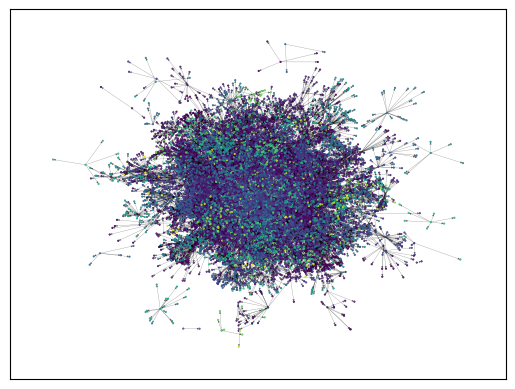

In [13]:
# Note that for a large dataset this can take some time (tens of minutes)
colors = community_ids
if toprint == 1:
    print("")
    print(G_networkX.nodes())
    print(colors)
    

#Plotting options
options = {
    'node_size': 10,
    'width': 0.1,
    'arrowsize': 5,
    'with_labels': False
}

node_size = 0.3

pos = nx.spring_layout(G_networkX)
cmap = plt.get_cmap('hsv', max(node_community.values()) + 1)

nx.draw_networkx_nodes(G_networkX, pos, nodelist=node_community.keys(), node_size=0.3, node_color=node_community.values())
nx.draw_networkx_edges(G_networkX, pos, alpha=0.5, width=0.2, arrowsize=3,node_size=node_size+0.2)

plt.savefig("../output/figures/output_OA.png",dpi=800)
plt.show()

## Trying with Louvain - not working at moment
Following: [https://github.com/taynaud/python-louvain](https://github.com/taynaud/python-louvain)

This might still be possible using [leidenalg package](https://leidenalg.readthedocs.io/en/stable/advanced.html) and can just edit above code

In [16]:
# compute the best partition using the louvian
#for key in partition:
#partition = community_louvain.best_partition(G_networkX)
#    print (key,partition[key])

In [17]:
# draw the graph
#pos = nx.spring_layout(G_networkX)
# color the nodes according to their partition
#cmap = plt.get_cmap('viridis', max(partition.values()) + 1)
#nx.draw_networkx_nodes(G_networkX, pos, partition.keys(), node_size=30,
#                       cmap=cmap, node_color=list(partition.values()))
#nx.draw_networkx_edges(G_networkX, pos, alpha=0.5)
#plt.show()

## Get community metrics and print results data